Load Sharjah data from SQLite

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
print(os.path.exists("/content/drive/MyDrive/smart_building_anomaly/db/sharjah.db"))

Mounted at /content/drive
True


In [4]:
import os
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

sns.set_theme(style="darkgrid")

PROJECT_ROOT = "/content/drive/MyDrive/smart_building_anomaly"
DB_PATH = PROJECT_ROOT + "/db/sharjah.db"

conn = sqlite3.connect(DB_PATH)
df_power = pd.read_sql("SELECT * FROM power_consumption", conn, parse_dates=["timestamp"])
df_temp = pd.read_sql("SELECT * FROM temperature", conn, parse_dates=["timestamp"])
df_humidity = pd.read_sql("SELECT * FROM humidity", conn, parse_dates=["timestamp"])
df_motion = pd.read_sql("SELECT * FROM motion", conn, parse_dates=["timestamp"])
conn.close()

print("Loaded from sharjah.db")
for name, df in [("power", df_power), ("temperature", df_temp), ("humidity", df_humidity), ("motion", df_motion)]:
    print("  " + name + ": " + str(df.shape))


Loaded from sharjah.db
  power: (2378, 3)
  temperature: (1058, 3)
  humidity: (1080, 3)
  motion: (1082, 3)


Anomaly detection functions (Z-score, IQR, Isolation Forest)

In [5]:
def detect_zscore(df, value_col, group_col, threshold=3.0):
    df = df.copy()
    df["zscore"] = df.groupby(group_col)[value_col].transform(
        lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) > 0 else 0
    )
    df["anomaly_zscore"] = df["zscore"].abs() > threshold
    return df

def detect_iqr(df, value_col, group_col, k=1.5):
    df = df.copy()
    def flag_group(x):
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        return (x < lower) | (x > upper)
    df["anomaly_iqr"] = df.groupby(group_col)[value_col].transform(flag_group)
    return df

def detect_isolation_forest(df, value_col, group_col, contamination=0.02, random_state=42):
    df = df.copy()
    df["anomaly_iforest"] = False
    for label, sub in df.groupby(group_col):
        if len(sub) < 10:
            continue
        X = sub[[value_col]].values
        model = IsolationForest(contamination=contamination, random_state=random_state)
        preds = model.fit_predict(X)
        df.loc[sub.index, "anomaly_iforest"] = preds == -1
    return df

def run_full_pipeline(df, value_col, group_col):
    df = detect_zscore(df, value_col, group_col)
    df = detect_iqr(df, value_col, group_col)
    df = detect_isolation_forest(df, value_col, group_col)
    df["anomaly_consensus"] = (
        df["anomaly_zscore"].astype(int)
        + df["anomaly_iqr"].astype(int)
        + df["anomaly_iforest"].astype(int)
    ) >= 2
    return df

print("Detection functions defined")


Detection functions defined


Run pipeline on all four streams

In [6]:
df_power_flagged = run_full_pipeline(df_power, "power_W", "appliance")
df_temp_flagged = run_full_pipeline(df_temp, "temp_C", "location")
df_humidity_flagged = run_full_pipeline(df_humidity, "humidity_pct", "location")
df_motion_flagged = run_full_pipeline(df_motion, "motion_value", "location")

print("Anomaly detection complete")

Anomaly detection complete


Summary report


In [7]:
def summarize(df, name):
    total = len(df)
    z = int(df["anomaly_zscore"].sum())
    iqr = int(df["anomaly_iqr"].sum())
    iforest = int(df["anomaly_iforest"].sum())
    consensus = int(df["anomaly_consensus"].sum())
    print("\n" + name.upper())
    print("  Total records     : " + str(total))
    print("  Z-score anomalies : " + str(z) + " (" + str(round(100*z/total, 2)) + "%)")
    print("  IQR anomalies     : " + str(iqr) + " (" + str(round(100*iqr/total, 2)) + "%)")
    print("  IsoForest anomalies: " + str(iforest) + " (" + str(round(100*iforest/total, 2)) + "%)")
    print("  Consensus (2+/3)  : " + str(consensus) + " (" + str(round(100*consensus/total, 2)) + "%)")

print("=" * 55)
print("     SHARJAH 2024 — ANOMALY DETECTION SUMMARY")
print("=" * 55)
summarize(df_power_flagged, "power")
summarize(df_temp_flagged, "temperature")
summarize(df_humidity_flagged, "humidity")
summarize(df_motion_flagged, "motion")

     SHARJAH 2024 — ANOMALY DETECTION SUMMARY

POWER
  Total records     : 2378
  Z-score anomalies : 32 (1.35%)
  IQR anomalies     : 253 (10.64%)
  IsoForest anomalies: 52 (2.19%)
  Consensus (2+/3)  : 44 (1.85%)

TEMPERATURE
  Total records     : 1058
  Z-score anomalies : 3 (0.28%)
  IQR anomalies     : 41 (3.88%)
  IsoForest anomalies: 22 (2.08%)
  Consensus (2+/3)  : 14 (1.32%)

HUMIDITY
  Total records     : 1080
  Z-score anomalies : 0 (0.0%)
  IQR anomalies     : 1 (0.09%)
  IsoForest anomalies: 24 (2.22%)
  Consensus (2+/3)  : 1 (0.09%)

MOTION
  Total records     : 1082
  Z-score anomalies : 17 (1.57%)
  IQR anomalies     : 183 (16.91%)
  IsoForest anomalies: 20 (1.85%)
  Consensus (2+/3)  : 20 (1.85%)


Save flagged data back to SQLite

In [8]:
conn = sqlite3.connect(DB_PATH)
df_power_flagged.to_sql("power_consumption_flagged", conn, if_exists="replace", index=False)
df_temp_flagged.to_sql("temperature_flagged", conn, if_exists="replace", index=False)
df_humidity_flagged.to_sql("humidity_flagged", conn, if_exists="replace", index=False)
df_motion_flagged.to_sql("motion_flagged", conn, if_exists="replace", index=False)
conn.close()

print("Flagged tables saved to sharjah.db")

Flagged tables saved to sharjah.db


Visualization: consensus anomalies over time

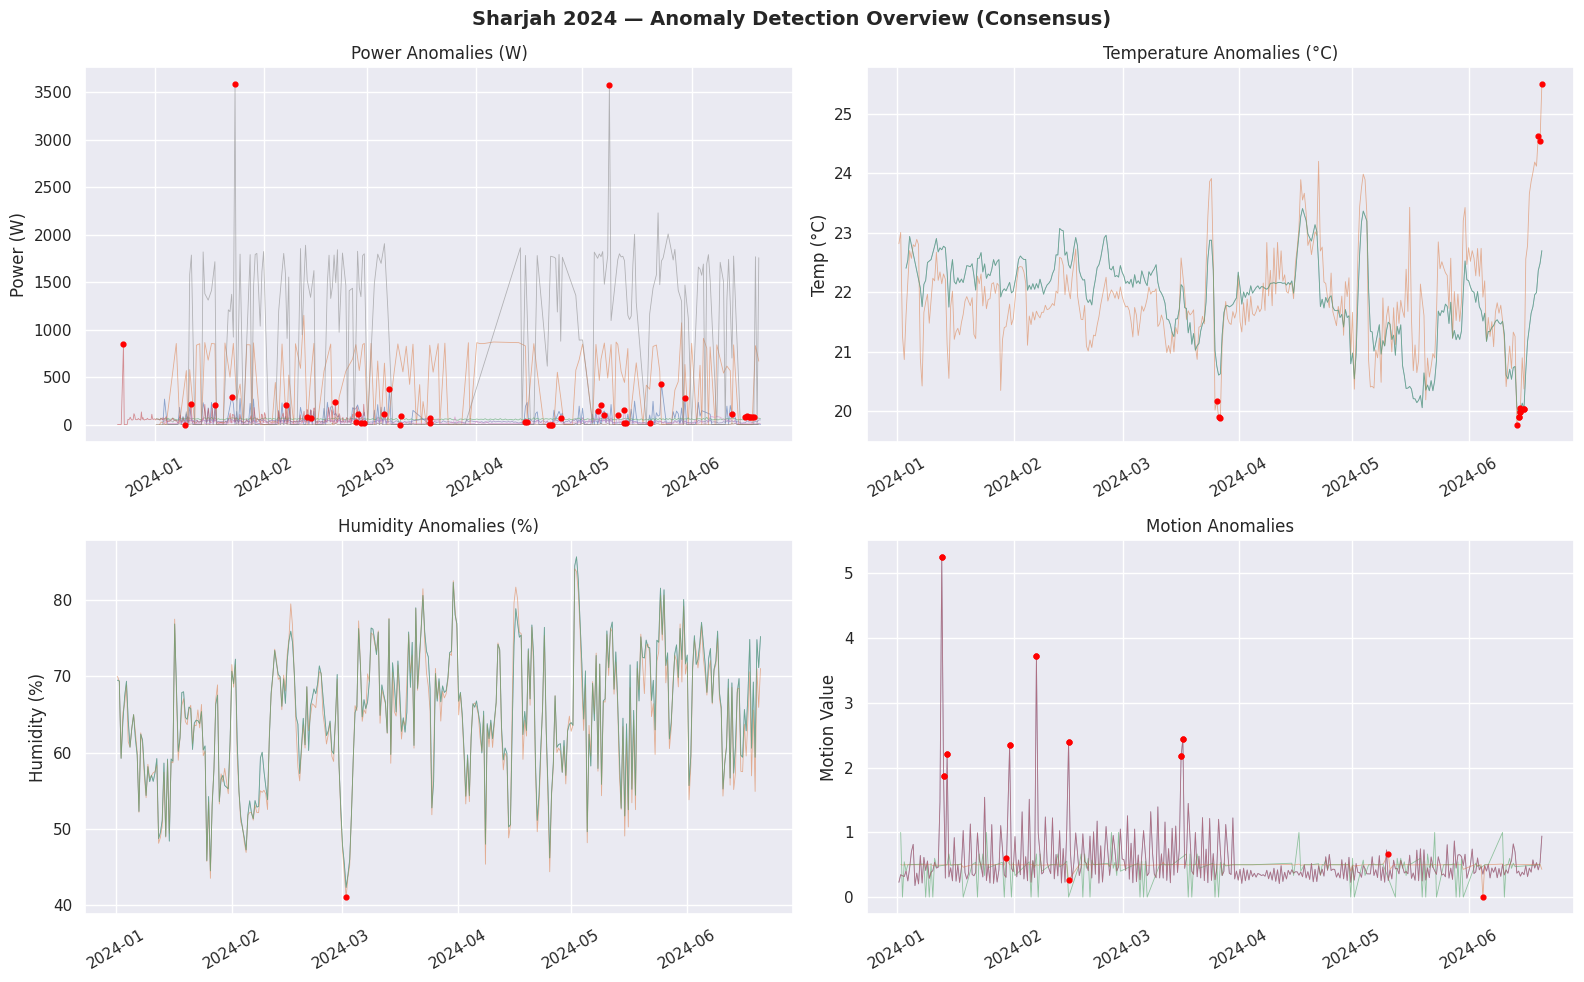

Plot saved: /content/drive/MyDrive/smart_building_anomaly/outputs/plots/sharjah_anomaly_overview.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Sharjah 2024 — Anomaly Detection Overview (Consensus)", fontsize=14, fontweight="bold")

def plot_stream(ax, df, value_col, group_col, title, ylabel):
    for label, sub in df.groupby(group_col):
        ax.plot(sub["timestamp"], sub[value_col], linewidth=0.6, alpha=0.6, label=label)
        anomalies = sub[sub["anomaly_consensus"]]
        ax.scatter(anomalies["timestamp"], anomalies[value_col], color="red", s=12, zorder=5)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)

plot_stream(axes[0, 0], df_power_flagged, "power_W", "appliance", "Power Anomalies (W)", "Power (W)")
plot_stream(axes[0, 1], df_temp_flagged, "temp_C", "location", "Temperature Anomalies (°C)", "Temp (°C)")
plot_stream(axes[1, 0], df_humidity_flagged, "humidity_pct", "location", "Humidity Anomalies (%)", "Humidity (%)")
plot_stream(axes[1, 1], df_motion_flagged, "motion_value", "location", "Motion Anomalies", "Motion Value")

plt.tight_layout()
plot_path = PROJECT_ROOT + "/outputs/plots/sharjah_anomaly_overview.png"
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: " + plot_path)